<!-- SPDX-License-Identifier: Apache-2.0 -->
<!-- Copyright (c) 2025 FlyDSL Project Contributors -->

# What is a `make_tile`?

`04_layout` built layouts; `05_tiled_copy_and_swizzle` spread a tile across threads and
*drew* it with `print_typst`. This one zooms in on the **tiler** itself — the `Tile`
you build with `fx.make_tile(...)` and hand to a divide (`zipped_divide` /
`logical_divide` / `flat_divide`) or to `make_tiled_copy` as its `tile_mn`.

A `Tile` is a **cookie-cutter**: an ordered list of one *mode per axis* that says how to
carve each dimension. We first print the real layouts the tilers produce, then — exactly
like the swizzle notebook — draw them with `print_typst`, colouring every cell by the
tile it belongs to so the carving is visible at a glance.

As before, the layout algebra runs inside a `@flyc.jit` (it needs the MLIR context); the
rendering happens afterwards on the host.

In [1]:
import os
import tempfile

# Disable the JIT disk cache: print_typst / print run as trace-time side effects, and a
# warm cache would skip the re-trace (and those side effects) on re-run. Set before import.
os.environ["FLYDSL_RUNTIME_ENABLE_CACHE"] = "0"

import torch  # noqa: F401  (parity with the sibling notebooks)
from IPython.display import SVG, Code, display

import flydsl.compiler as flyc
import flydsl.expr as fx

try:
    import typst  # `pip install typst` — bundles the compiler
except ImportError:
    typst = None

_TYP_DIR = tempfile.mkdtemp()


def render_typst(name):
    """Show a Typst file written by print_typst: inline SVG when `typst` is available,
    otherwise the raw Typst source."""
    path = os.path.join(_TYP_DIR, name)
    if typst is None:
        with open(path) as f:
            display(Code(f.read(), language="typst"))
        return
    out = typst.compile(path, format="svg")
    if isinstance(out, list):  # one entry per page; our files are single-page
        out = out[0]
    if isinstance(out, (bytes, bytearray)):
        out = out.decode()
    display(SVG(out))


# One pastel colour per tile.
_PAL = ["#afafff", "#afffaf", "#ffffaf", "#ffafaf", "#d2d2ff", "#d2ffd2", "#ffffd2", "#ffd2d2"]

# Two-level palette: 4 hue families (outer tile) x 4 shades (inner sub-structure).
_PAL16 = [
    "#e6ebff", "#bcc9ff", "#93a7ff", "#6a85ff",  # blues
    "#e7f9e7", "#bdeebd", "#94e294", "#6bd76b",  # greens
    "#fcfcd2", "#f6f6a2", "#eaea63", "#d0d043",  # yellows
    "#ffe6e6", "#ffbcbc", "#ff9393", "#f26a6a",  # reds
]


def _esc(s):
    """Match print_typst's Typst text escaping (so we can find/replace its header)."""
    return s.replace("\\", "\\\\").replace("[", "\\[").replace("]", "\\]").replace("<", "\\<").replace(">", "\\>").replace(" ", "~")


def _w(obj, name, color=None, label=None):
    """Overwrite-then-write a Typst diagram of `obj`, so re-running is idempotent
    (print_typst *appends*). `color(idx) -> hex` optionally shades each cell.

    We draw the *base* layout coloured by tile, so print_typst's header would show the
    base's string for every grid. `label` rewrites that header to name the real tiler."""
    p = os.path.join(_TYP_DIR, name)
    if os.path.exists(p):
        os.remove(p)
    fx.utils.print_typst(obj, color=color, file=p)
    if label is not None:
        txt = open(p).read().replace(_esc(str(obj)), _esc(label), 1)
        with open(p, "w") as f:
            f.write(txt)


def group_of(divided, key):
    """Map each source address -> a group id, read from the ACTUAL divide result via
    crd2idx (not a hand-written formula). `key(lin)` picks what to group by: the tile id,
    an interior sub-coordinate, etc. A divide is a bijection over the addresses, and the
    interior mode enumerates fastest."""
    t = {}
    for lin in range(fx.size(divided).to_py_value()):
        addr = fx.crd2idx(lin, divided).get_static_leaf_int
        t[addr] = key(lin)
    return t


def tile_of(divided, tile_elems):
    """Group by tile id: the interior is fastest, so linear // tile_elems is the tile."""
    return group_of(divided, lambda lin: lin // tile_elems)


def nested_key(lin):
    """Two-level id for the row-nested tile ((2,2),4) with 4 outer tiles: outer quadrant
    (hue) * 4 + WHICH (2,2) subtile (shade). The (2,2) has vertical strides (8,16), so one
    subtile is a vertical 4-run like {0,8,16,24}; the 4 subtiles are indexed by the flat
    column mode = `interior // 4`. (Colouring by `interior % 4` instead would group the
    k-th cell of every subtile, which comes out row-wise.)"""
    return (lin // 16) * 4 + (lin % 16) // 4

## 1. The tiler modes

A `Tile` has one **mode per axis**, and each mode is one of:

* **int `N`** — a contiguous run of `N`. Shorthand for the layout `<N:1>`.
* **Layout `<N:s>`** — `N` elements spaced by `s` (strided / interleaved sub-tile).
* **Layout `<(a,b):..>`** — a nested (hierarchical) sub-tile of that one axis.

The *number* of modes matters too: a tiler with **fewer** modes than the tensor's rank
leaves the trailing axes untiled (that is how you "skip" an axis). A bare `None` mode and
a bare nested int-tuple like `(2, 2)` are **not** accepted by these divides — use a short
tiler to skip, and a nested `Layout` for hierarchy.

The cell below feeds each tiler to a divide and prints the resulting `<shape:stride>`.
Read a divide result as **(Tile, Rest)**: the Tile modes are the coordinates *inside* one
tile, the Rest modes say *which* tile.

In [2]:
@flyc.jit
def tile_text():
    v = fx.make_layout(8, 1)
    print("vector                     ", v)
    print("  make_tile(4)      int==<4:1>", fx.logical_divide(v, fx.make_tile(4)))
    print("  make_tile(<4:1>)  blocked  ", fx.logical_divide(v, fx.make_tile(fx.make_layout(4, 1))))
    print("  make_tile(<4:2>)  interleaved", fx.logical_divide(v, fx.make_tile(fx.make_layout(4, 2))))

    a = fx.make_layout((8, 8), (8, 1))
    print("matrix 8x8 row-major       ", a)
    print("  make_tile(2, 4)   both axes", fx.zipped_divide(a, fx.make_tile(2, 4)))
    print("  make_tile(<2:1>,<4:2>) mixed", fx.zipped_divide(a, fx.make_tile(fx.make_layout(2, 1), fx.make_layout(4, 2))))
    print("  make_tile(2)      axis-0 only -> 2x1 tiles", fx.zipped_divide(a, fx.make_tile(2)))
    print("  make_tile(<(2,2):(1,2)>,4) nested", fx.zipped_divide(a, fx.make_tile(fx.make_layout((2, 2), (1, 2)), 4)))


tile_text()

vector                      Layout<8:1>
  make_tile(4)      int==<4:1> Layout<(4,2):(1,4)>
  make_tile(<4:1>)  blocked   Layout<(4,2):(1,4)>
  make_tile(<4:2>)  interleaved Layout<(4,2):(2,1)>
matrix 8x8 row-major        Layout<(8,8):(8,1)>
  make_tile(2, 4)   both axes Layout<((2,4),(4,2)):((8,1),(16,4))>
  make_tile(<2:1>,<4:2>) mixed Layout<((2,4),(4,2)):((8,2),(16,1))>
  make_tile(2)      axis-0 only -> 2x1 tiles Layout<(2,(4,8)):(8,(16,1))>
  make_tile(<(2,2):(1,2)>,4) nested Layout<(((2,2),4),(2,2)):(((8,16),1),(32,4))>


## 2. Seeing it — `print_typst`

Strides are easier to *see* than to read. `fx.utils.print_typst(layout, ...)` writes a
[Typst](https://typst.app) grid of a layout — one cell per element, labelled with its
address — and `render_typst` compiles it to inline SVG (falling back to raw source
without the `typst` package).

We draw each grid on the **natural (row, col)** layout — cells stay where they live in the
matrix — and **shade each cell by the tile it belongs to** (same colour = same tile). The
tile id is *not* hand-computed: `tile_of` reads it from the **actual divide result** via
`crd2idx`, so the colouring is the DSL's real partition painted back onto the natural grid.

(Aside: `print_typst` of a *divide-result* layout is faithful too, but it flattens the
nested `((Tile),(Rest))` into a 2-D grid where a column is a whole flattened tile — easy to
misread. Colouring the natural grid avoids that, which is how `05_tiled_copy_and_swizzle`
shows per-thread ownership.)

In [3]:
@flyc.jit
def emit():
    vecbase = fx.make_layout((1, 8), (1, 1))   # the 8 elements drawn as a natural row
    mat = fx.make_layout((8, 8), (8, 1))        # the 8x8 drawn in natural (row, col)

    def draw(base, divided, tile_elems, name, label):
        # Colour the NATURAL grid: each cell (labelled with its address) is shaded by the
        # tile it lands in, and that tile id is read from `divided` via crd2idx — so the
        # colouring is the DSL's real partition, just painted back onto the (row, col) grid.
        # `label` names the tiler + the real divide result in the diagram header.
        tof = tile_of(divided, tile_elems)
        _w(base, name, color=lambda idx: _PAL[tof[idx] % len(_PAL)], label=f"{label}  ->  {divided}")

    v = fx.make_layout(8, 1)
    draw(vecbase, fx.logical_divide(v, fx.make_tile(4)), 4, "vec_block.typ", "make_tile(4)")
    draw(vecbase, fx.logical_divide(v, fx.make_tile(fx.make_layout(4, 2))), 4, "vec_inter.typ", "make_tile(<4:2>)")

    _w(mat, "mat_plain.typ", label="8x8 row-major (base, shaded by index)")
    draw(mat, fx.zipped_divide(mat, fx.make_tile(2, 4)), 8, "mat_2x4.typ", "make_tile(2, 4)")
    draw(mat, fx.zipped_divide(mat, fx.make_tile(fx.make_layout(2, 1), fx.make_layout(4, 2))), 8, "mat_mixed.typ", "make_tile(<2:1>, <4:2>)")
    draw(mat, fx.zipped_divide(mat, fx.make_tile(2)), 2, "mat_short.typ", "make_tile(2)")
    # Row-nested tile ((2,2),4): 4 outer quadrants. Two-level colour: outer tile
    # (quadrant) = HUE, WHICH (2,2) subtile = SHADE. Each (2,2) is a vertical 4-run
    # (strides 8,16), so a shade groups a column like {0,8,16,24}.
    divn = fx.zipped_divide(mat, fx.make_tile(fx.make_layout((2, 2), (1, 2)), 4))
    grpn = group_of(divn, nested_key)
    _w(mat, "mat_nested.typ", color=lambda idx: _PAL16[grpn[idx]],
       label=f"make_tile(<(2,2):(1,2)>, 4)  [hue=tile, shade=which (2,2) subtile]  ->  {divn}")


emit()

### 1-D: the stride lever

The 8 elements drawn as a natural row, two colours = two tiles. `make_tile(4)` (`<4:1>`)
gives **contiguous** tiles — left half `{0,1,2,3}`, right half `{4,5,6,7}`.
`make_tile(<4:2>)` keeps 4-per-tile but **stride-2**, so the colours **alternate** —
`{0,2,4,6}` vs `{1,3,5,7}`. Same counts, different members: the stride knob, visible.

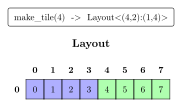

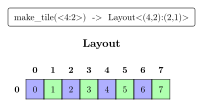

In [4]:
render_typst("vec_block.typ")
render_typst("vec_inter.typ")

### 2-D: one mode per axis

The base 8×8 (grayscale index grid), then `make_tile(2, 4)` painted on the natural grid:
**eight 2×4 coloured blocks**, exactly the tiles. Tile 0 is the top-left block (rows 0–1 ×
cols 0–3 = addresses `{0,1,2,3, 8,9,10,11}`), and the colours march across then down —
which is what the `Rest` coordinate counts.

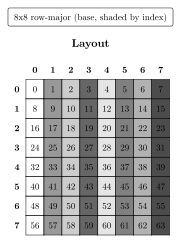

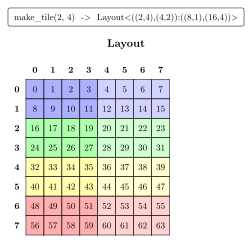

In [5]:
render_typst("mat_plain.typ")
render_typst("mat_2x4.typ")

### Mixing modes, and skipping an axis

`make_tile(<2:1>, <4:2>)` keeps 2 contiguous rows but makes the **columns stride-2**, so
each coloured tile is 2 rows × **every-other column** — the colours **stripe** across the
columns instead of forming solid 2×4 blocks.

`make_tile(2)` is a **short tiler**: one mode tiles axis 0 only (`(2,(4,8)):(8,(16,1))`).
The tile mode `2:8` is *two vertically-adjacent rows in one column*, so you see **2×1
vertical dominoes** — 32 of them — not full-width row bands. "Skipping" the column axis
means every column is tiled on its own.

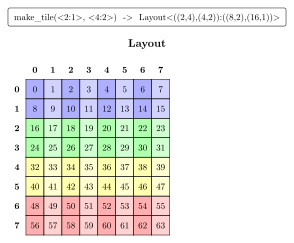

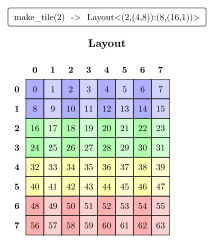

In [6]:
render_typst("mat_mixed.typ")
render_typst("mat_short.typ")

### Nested (hierarchical) mode

`make_tile(<(2,2):(1,2)>, 4)` nests a `Layout` on the **row** mode only (the column mode is
a flat `4`). This diagram is **two-level**: the **hue** is the outer tile — four 4×4
quadrants (the `(2,2)` we have four of) — and the **shade** is the inner `(2,2)` index.

The key subtlety is *what a subtile is*. The `(2,2)` has **vertical** strides `(8,16)`
(both multiples of the row stride 8), so **one `(2,2)` subtile is a vertical 4-run** — e.g.
`{0, 8, 16, 24}`, going straight down a column. There are **4 subtiles per quadrant** (one
per column, the flat `4` mode), so a shade groups a whole column and you see four vertical
stripes:

```
0 1 2 3        (within one quadrant: shade = which (2,2) subtile;
0 1 2 3         subtile 0 = column {0,8,16,24}, subtile 1 = {1,9,17,25}, ...)
0 1 2 3
0 1 2 3
```

So the nested `(2,2)` isn't a 2×2 *square* of cells — it's a vertical run, because only the
row axis is nested and its strides point down the rows. (Nesting the column mode too, e.g.
`make_tile(<(2,2):(1,2)>, <(2,2):(1,2)>)`, is what would make each subtile a 2×2 square.)
That is the whole point: a `Layout` mode structures — and strides along — *its own axis*.

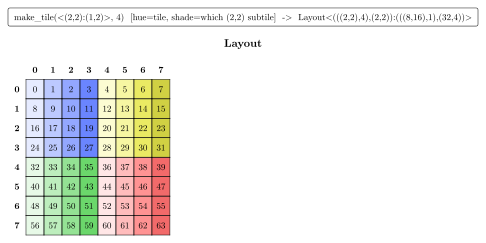

In [7]:
render_typst("mat_nested.typ")

## Where you actually use it

That is `make_tile` end to end: one mode per axis (int = contiguous `<N:1>`, `Layout` =
strided or nested), a short tiler to skip trailing axes, and a plain tuple auto-wraps to
`make_tile(...)` — so `fx.zipped_divide(A, (2, 4))` **is** `make_tile(2, 4)`.

The same object names the per-block footprint (`tile_mn`) inside
`make_tiled_copy_{A,B,C}` — the bridge to `05_tiled_copy_and_swizzle`, where a tile is
then spread across threads.

Each coloured grid above is the natural matrix shaded by tile, where the tile of every
address is read from the real divide result via `crd2idx` (see `tile_of`) — so the picture
is the DSL's own partition, not a redrawing. This is the same idea as the per-thread
`TiledCopy` colouring in `05_tiled_copy_and_swizzle`.

---
*Companion source: `learn_fmha/tile_playground.py` (text) and `learn_fmha/divide_playground.py` (the four divide flavours).*